In [24]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [25]:
iris = load_iris()

X = pd.DataFrame(iris.data)
X.columns=iris.feature_names
y = iris.target

In [26]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


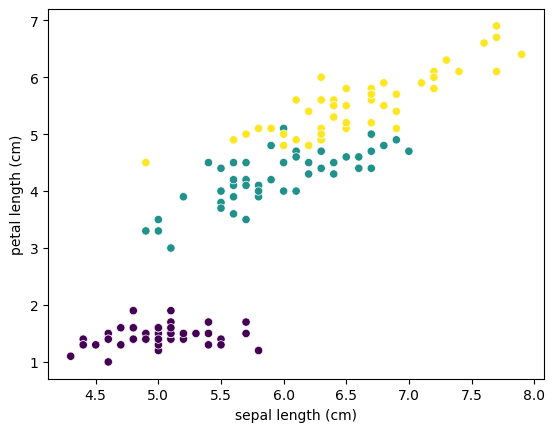

In [27]:
import matplotlib.pyplot as plt
sns.scatterplot(
    x=X.iloc[:, 0],
    y=X.iloc[:, 2],
    c=y
)
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(X_scaled)

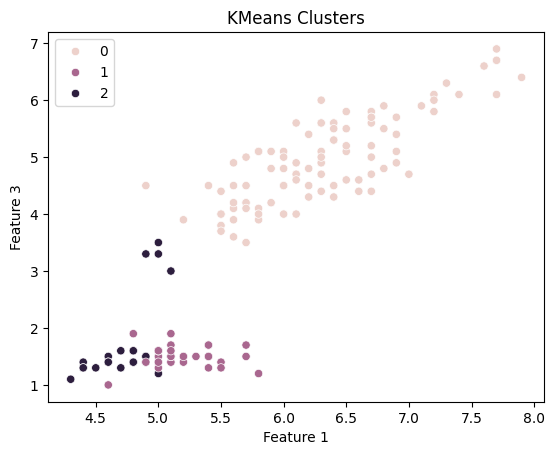

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x=X.iloc[:, 0],
    y=X.iloc[:, 2],
    hue=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 3")
plt.title("KMeans Clusters")
plt.show()

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(150, 3)


In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

labels = kmeans.fit_predict(X_pca)

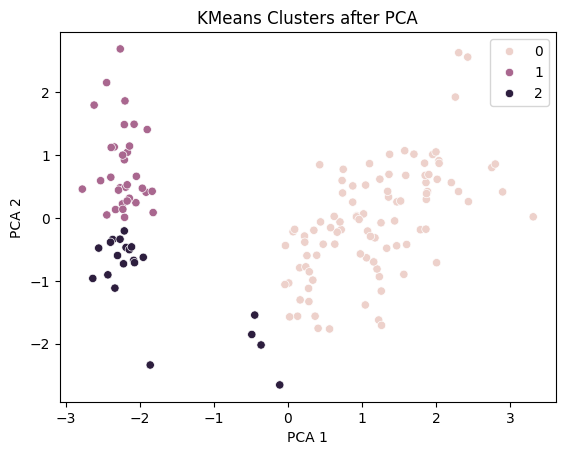

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clusters after PCA")
plt.show()

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [38]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [39]:
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [40]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [41]:
wcss = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

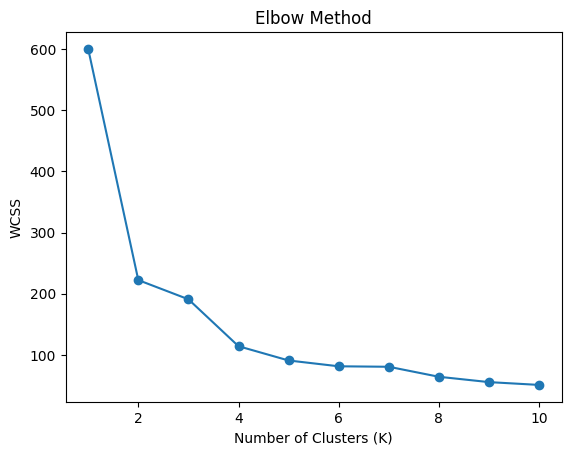

In [42]:
plt.plot(k_values, wcss, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [43]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

labels = kmeans.fit_predict(X_scaled)

print(labels)

[1 2 2 2 1 1 1 1 2 2 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 2 1 1 1 2 2 1
 1 2 1 1 2 2 1 1 2 1 2 1 1 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [44]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (150, 4)
PCA shape: (150, 2)


In [45]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

labels_pca = kmeans_pca.fit_predict(X_pca)

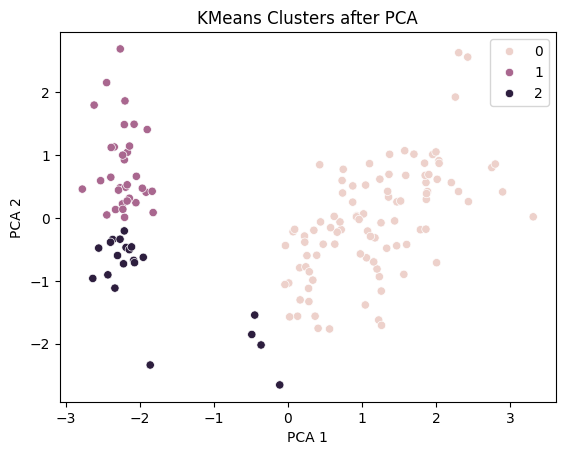

In [46]:
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_pca
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("KMeans Clusters after PCA")

plt.show()

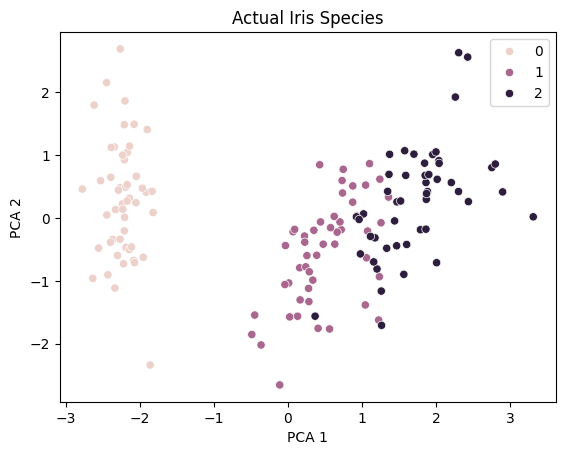

In [47]:
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Actual Iris Species")

plt.show()